In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [2]:
from probts.model.forecaster import LinearForecaster, NaiveForecaster
from probts.model.forecast_module import ProbTSForecastModule
from probts.data import ProbTSDataModule, DataManager, ProbTSBatchData
from probts.utils import find_best_epoch
from lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
import torch
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn

from probts.model.forecaster import Forecaster
class LinearForecaster(Forecaster):
    def __init__(
        self,
        individual: bool = True,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.individual = individual
        
        if self.individual:
            self.linear = nn.ModuleList()
            for i in range(self.input_size):
                self.linear.append(nn.Linear(self.context_length, self.prediction_length))
        else:
            self.linear = nn.Linear(self.context_length, self.prediction_length)
        self.out_linear = nn.Linear(self.input_size, self.target_dim)
        self.loss_fn = nn.MSELoss(reduction='none')

    def forward(self, x):
        if self.individual:
            outputs = torch.zeros([x.size(0), self.prediction_length, x.size(2)], dtype=x.dtype).to(x.device)
            for i in range(self.input_size):
                outputs[:, :, i] = self.linear[i](x[:, :, i])
        else:
            outputs = self.linear(x.permute(0,2,1)).permute(0,2,1)
        outputs = self.out_linear(outputs)
        return outputs

    def forecast(self, batch_data, num_samples=None):
        inputs = self.get_inputs(batch_data, 'encode')
        forecasts = self(inputs).unsqueeze(1)
        return forecasts

    def loss(self, batch_data):
        inputs = self.get_inputs(batch_data, 'encode')
        outputs = self(inputs)
        
        loss = self.loss_fn(batch_data.future_target_cdf, outputs)
        loss = self.get_weighted_loss(batch_data, loss)
        return loss.mean()

In [4]:
data_manager = DataManager(
    dataset='etth1', 
    path='../datasets', 
    context_length=96, 
    prediction_length=96,
    scaler='standard',
)
data_module = ProbTSDataModule(
    data_manager=data_manager,
    batch_size=32, 
    test_batch_size=32,
    num_workers=0,
)
test_dataloader = data_module.test_dataloader()
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

Loading Long-term Dataset: etth1
val  pred_len: 96 : num_test_windows: 29
test  pred_len: 96 : num_test_windows: 29
Test context length: [96], prediction length: [96]
Validation context length: [96], prediction length: [96]
Training context length: [96], prediction lengths: [96]
Test rolling length: 96
Variable-specific normalization: True


/Users/vitaliypozdnyakov/Yandex.Disk.localized/Data Science/ProbTS/probts/data/data_utils/get_datasets.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stamp['date'] = pd.to_datetime(df_stamp.date, format=data_format)


In [6]:
for test_batch in test_dataloader:
    break

In [6]:
forecaster = LinearForecaster(
    individual=True,
    use_lags=False,
    use_feat_idx_emb=False,
    use_time_feat=False,
    target_dim=data_manager.target_dim, 
    context_length=data_manager.context_length,
    prediction_length=data_manager.prediction_length,
    freq=data_manager.freq,
    lags_list=data_manager.lags_list,
    time_feat_dim=data_manager.time_feat_dim,
    dataset=data_manager.dataset,
)
model = ProbTSForecastModule(
    forecaster=forecaster, 
    scaler=data_manager.scaler, 
    learning_rate=0.005, 
    quantiles_num=20,
)

sampling_weight_scheme: none


/Users/vitaliypozdnyakov/miniconda3/envs/tsgrisk/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'forecaster' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['forecaster'])`.


In [7]:
trainer = Trainer(
    accelerator="cpu",
    devices=1,
    strategy="auto",
    max_epochs=5,
    use_distributed_sampler=False,
    limit_train_batches=100,
    log_every_n_steps=1,
    accumulate_grad_batches=1,
    default_root_dir='./results',
    logger=CSVLogger('./logs'),
)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/tsgrisk/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [8]:
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)


  | Name       | Type             | Params | Mode 
--------------------------------------------------------
0 | forecaster | LinearForecaster | 65.2 K | train
--------------------------------------------------------
65.2 K    Trainable params
0         Non-trainable params
65.2 K    Total params
0.261     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

/Users/vitaliypozdnyakov/miniconda3/envs/tsgrisk/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:420: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/Users/vitaliypozdnyakov/miniconda3/envs/tsgrisk/lib/python3.10/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/Users/vitaliypozdnyakov/miniconda3/envs/tsgrisk/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=5` reached.


In [9]:
batch_data = ProbTSBatchData(test_batch, model.device)
past_target_cdf = model.scaler.transform(batch_data.past_target_cdf)
future_target_cdf = model.scaler.transform(batch_data.future_target_cdf)
batch_data.past_target_cdf = past_target_cdf

batch_idx = 3
with torch.no_grad():
    prediction = model.forecaster.forecast(batch_data)
prediction = prediction[batch_idx, 0, :, :]
prediction.shape

torch.Size([96, 7])

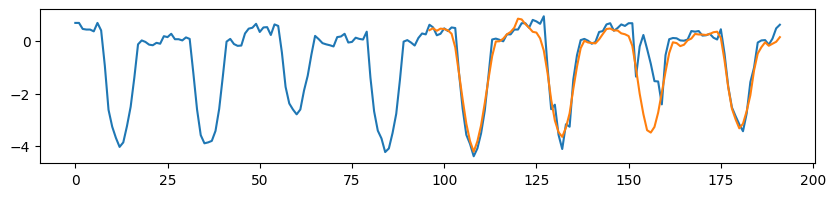

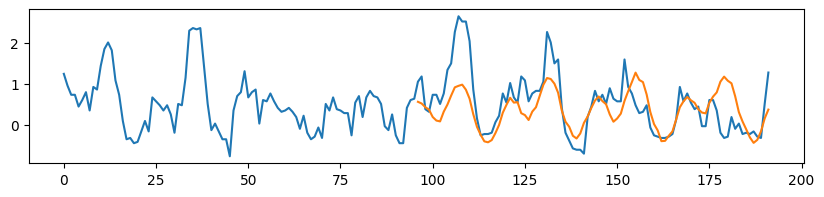

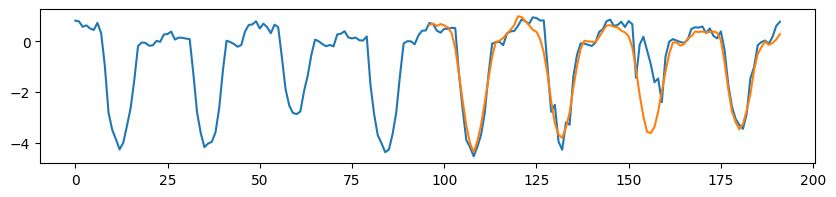

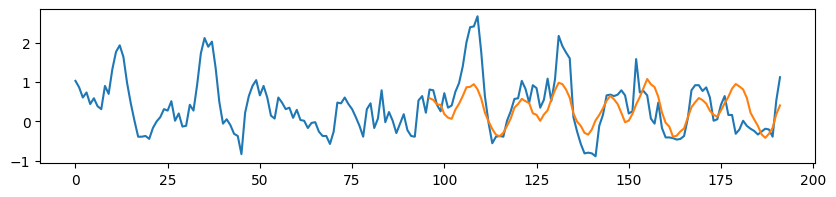

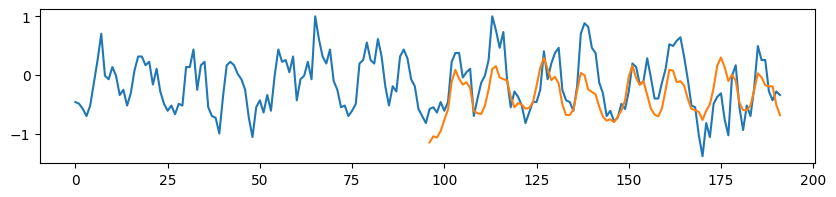

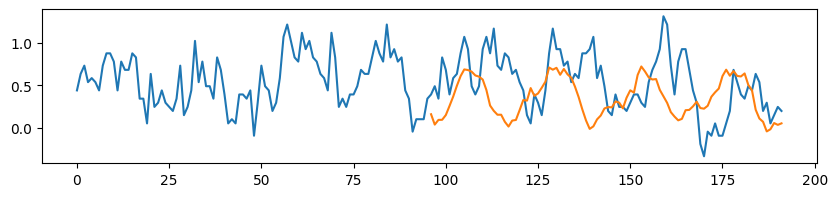

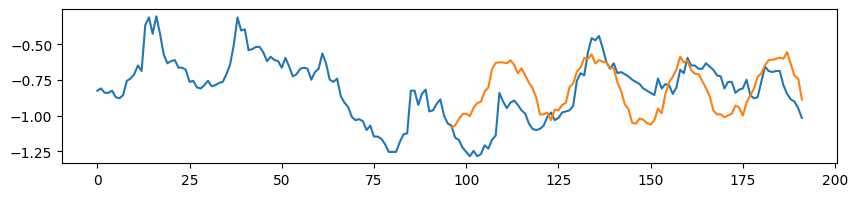

In [10]:
context_length = data_manager.context_length
prediction_length = data_manager.prediction_length
past_range = range(0, context_length)
future_range = range(context_length, context_length + prediction_length)
full_range = range(0, context_length + prediction_length)

for i in range(min(10, forecaster.target_dim)):
    target = torch.cat([past_target_cdf[batch_idx, -context_length:, i], future_target_cdf[batch_idx, :, i]])
    plt.figure(figsize=(10, 2))
    plt.plot(full_range, target)
    plt.plot(future_range, prediction[:, i])

In [11]:
trainer.test(model=model, datamodule=data_module);

/Users/vitaliypozdnyakov/miniconda3/envs/tsgrisk/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:420: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |                                                                                       | 0/? [00:00<…

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      96_test_CRPS          0.3470509946346283
    96_test_CRPS-Sum        0.2766629755496979
      96_test_MASE          1.2069823741912842
       96_test_MSE           8.964372634887695
     96_test_MSE-Sum        112.40438079833984
       96_test_ND           0.3470509946346283
     96_test_ND-Sum         0.2766629755496979
      96_test_NRMSE         0.6173792481422424
    96_test_NRMSE-Sum       0.36065128445625305
   96_test_weighted_ND      0.3470509946346283
 96_test_weighted_ND-Sum    0.2766629755496979
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
